In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
data_path = Path("data/Spam_data.csv")
if not data_path.exists():
    raise FileNotFoundError("Dataset not found at data/Spam_data.csv")

df = pd.read_csv(data_path)
print("Original shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Original shape: (3063, 4)
Columns: ['email', 'label', 'Subject', 'content']


,email,label,Subject,content
0,"b""From fork-admin@xent.com Tue Sep 17 18:42:3...",0.0,hanson' sept number messag nation review,chuck murcko wrote usual crud moron rant beat ...
1,b'From rssfeeds@jmason.org Tue Sep 24 10:47:4...,0.0,gold lake mountain resort look pretti gooood m...,url number number amgold lake mountain look pr...
2,b'From rpm-list-admin@freshrpms.net Mon Sep ...,0.0,pleas help newbi compil mplayer,upon time rob wrote dl'd gccnumber still get e...
3,b'From exmh-workers-admin@redhat.com Fri Aug ...,0.0,anolth sequenc relat traceback,date fri number aug number number number rober...
4,"b""From fork-admin@xent.com Fri Aug 23 11:08:3...",0.0,NaN,appar quot dubya time sent blair' special geor...


In [3]:
text_candidates = ["text", "content", "email", "message", "body", "Subject"]
label_candidates = ["label", "target", "class", "Category"]

text_col = next((c for c in text_candidates if c in df.columns), None)
label_col = next((c for c in label_candidates if c in df.columns), None)

if text_col is None or label_col is None:
    raise ValueError(f"Could not infer text/label columns. Found: {list(df.columns)}")

print("Text column:", text_col)
print("Label column:", label_col)

work = df[[text_col, label_col]].dropna().copy()
work[text_col] = work[text_col].astype(str)
raw_labels = work[label_col].astype(str).str.lower().str.strip()

label_map = {
    "spam": 1,
    "ham": 0,
    "not spam": 0,
    "non-spam": 0,
    "0": 0,
    "1": 1,
    "0.0": 0,
    "1.0": 1,
}

work["y"] = raw_labels.map(label_map)

if work["y"].isna().any():
    numeric = pd.to_numeric(raw_labels, errors="coerce")
    work.loc[work["y"].isna(), "y"] = (numeric[work["y"].isna()] >= 0.5).astype(int)

if work["y"].isna().any():
    unique_labels = sorted(raw_labels.unique())
    raise ValueError(f"Unmapped labels found: {unique_labels}")

work["y"] = work["y"].astype(int)
print("Clean shape:", work.shape)
print(work["y"].value_counts())

Text column: content
Label column: label
Clean shape: (3059, 3)
y
0    2658
1     401
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    work[text_col],
    work["y"],
    test_size=0.2,
    random_state=42,
    stratify=work["y"],
)

model = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, max_df=0.95)),
        ("clf", LogisticRegression(max_iter=400, class_weight="balanced", random_state=42)),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

           0     0.9869    0.9887    0.9878       532
           1     0.9241    0.9125    0.9182        80

    accuracy                         0.9788       612
   macro avg     0.9555    0.9506    0.9530       612
weighted avg     0.9787    0.9788    0.9787       612

ROC-AUC: 0.9971


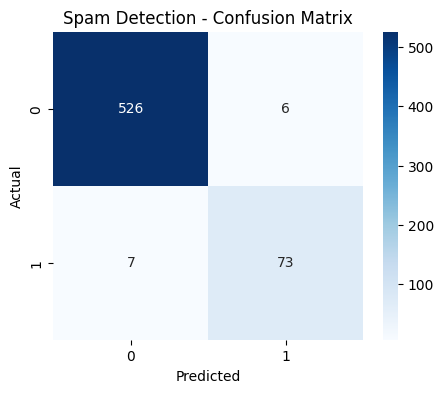

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Spam Detection - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()